**Computer assignment 3**

***Zakiye Amin***

***810102398***

In [617]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import joblib
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from collections import Counter

***Load data***

In [618]:
train_df = pd.read_csv('Grades.csv')

***Preproccessing and feature engineering***

- Check for missing values

In [619]:
assert not train_df.isnull().any().any()

In [620]:
if train_df.isnull().sum().sum() != 0:
    print("Missing values found:")
    print(train_df.isnull().sum())
else:
    print("No Missing Value!")

No Missing Value!


- Check for duplicated row

In [621]:
duplicate_count = train_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 2


In [622]:
train_df = train_df.drop_duplicates()

- Encode Categorical Variables

In [623]:
labels = ['universitySupport', 'paid', 'higher', 'internet', 'romantic']
for label in labels:
    train_df[label] = train_df[label].map({'yes': 1, 'no': 0})


- One-Hot Encoding

In [624]:
train_df['motherEducation'] = pd.Categorical(train_df['motherEducation'], categories=[0, 1, 2, 3, 4])
train_df['fatherEducation'] = pd.Categorical(train_df['fatherEducation'], categories=[0, 1, 2, 3, 4])
train_df['university'] = pd.Categorical(train_df['university'], categories=['PR', 'CM'])
train_df['reason'] = pd.Categorical(train_df['reason'], categories=['home', 'reputation', 'course', 'other'])
train_df['sex'] = pd.Categorical(train_df['sex'], categories=['F', 'M'])
train_df['motherJob'] = pd.Categorical(train_df['motherJob'], categories=['teacher', 'health', 'services', 'at_home', 'other'])
train_df['fatherJob'] = pd.Categorical(train_df['fatherJob'], categories=['teacher', 'health', 'services', 'at_home', 'other'])
train_df['address'] = pd.Categorical(train_df['address'], categories=['U', 'R'])
train_df['travelTime'] = pd.Categorical(train_df['travelTime'], categories=[1, 2, 3, 4])
train_df['studyTime'] = pd.Categorical(train_df['studyTime'], categories=[1, 2, 3, 4])


mother_edu_dummies = pd.get_dummies(train_df['motherEducation'], prefix='motherEducation')
father_edu_dummies = pd.get_dummies(train_df['fatherEducation'], prefix='fatherEducation')
uni_dummies = pd.get_dummies(train_df['university'], prefix='university')
reason_dummies = pd.get_dummies(train_df['reason'], prefix='reason')
sex_dummies = pd.get_dummies(train_df['sex'], prefix='sex')
mother_job_dummies = pd.get_dummies(train_df['motherJob'], prefix='motherJob')
father_job_dummies = pd.get_dummies(train_df['fatherJob'], prefix='fatherJob')
address_dummies = pd.get_dummies(train_df['address'], prefix='address')
travel_time_dummies = pd.get_dummies(train_df['travelTime'], prefix='travelTime')
study_time_dummies = pd.get_dummies(train_df['studyTime'], prefix='studyTime')

train_df = pd.concat([train_df, mother_edu_dummies, father_edu_dummies, uni_dummies, reason_dummies,
                      sex_dummies, mother_job_dummies, father_job_dummies, address_dummies, 
                      travel_time_dummies, study_time_dummies], axis=1)

categorical_columns = [
    'motherEducation', 'fatherEducation', 'university', 'reason', 'sex',
    'motherJob', 'fatherJob', 'address', 'travelTime', 'studyTime'
]

train_df.drop(columns=categorical_columns, inplace=True)
train_df = train_df.astype(int)


In [625]:
# train_df = pd.get_dummies(train_df, columns=[
#     'university','reason', 'motherEducation', 'fatherEducation'
#     ,'sex',  'motherJob', 'fatherJob', 'address', 'travelTime',
#     'studyTime'], drop_first=True)
# train_df.to_csv("sos.csv")
# train_df = train_df.astype(int)

- correlation matrix

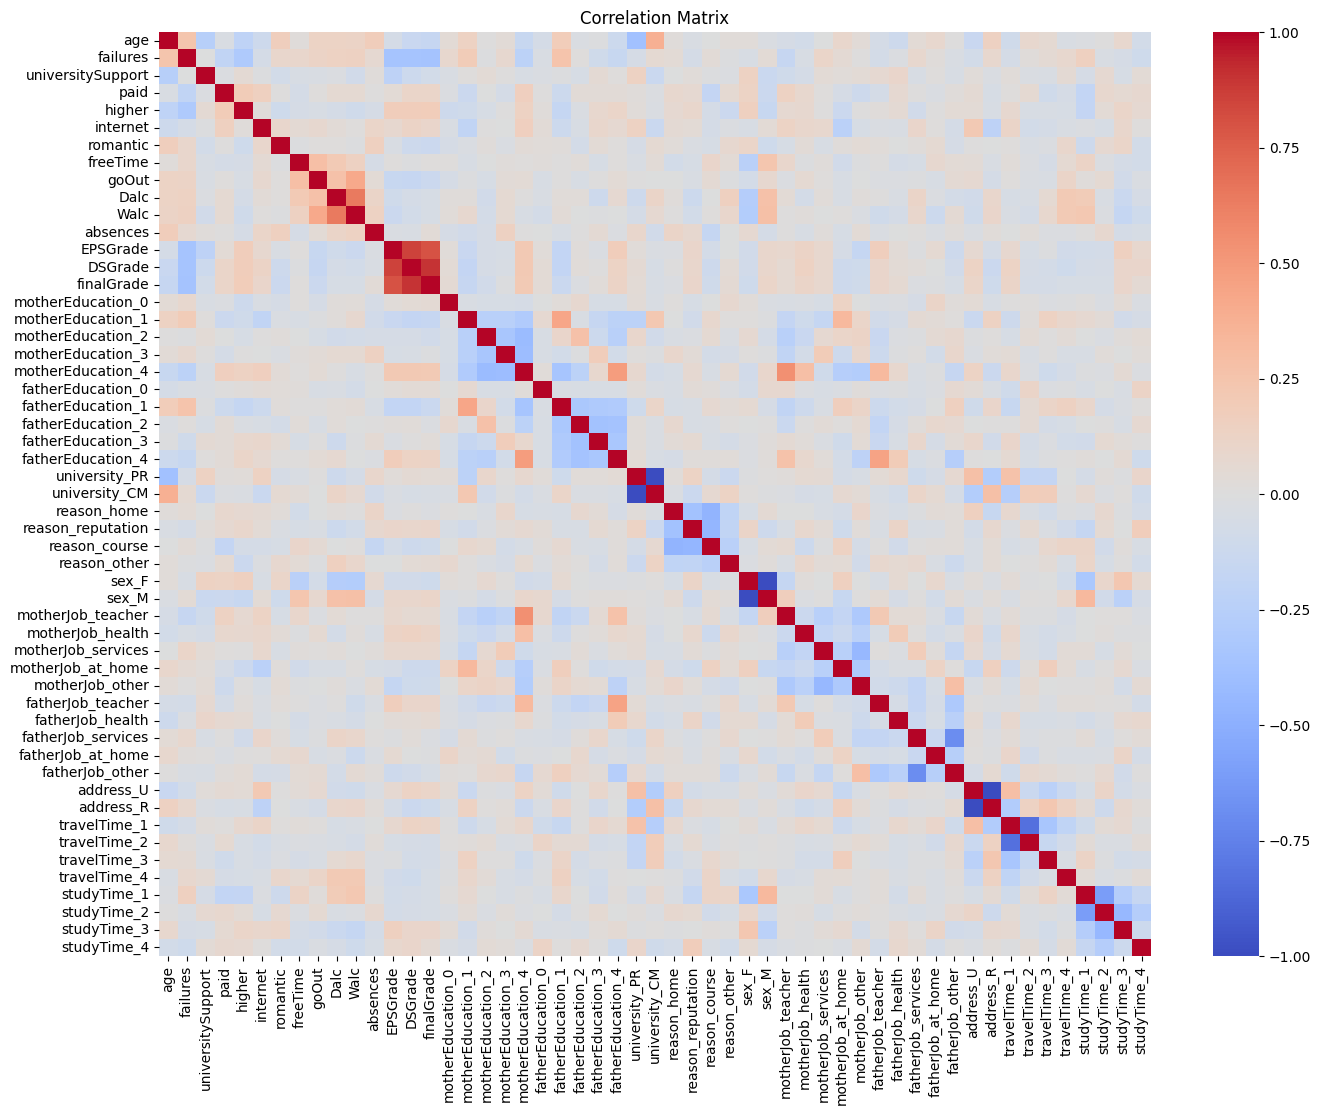

In [626]:
corr = train_df.corr(numeric_only=True)
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

In [627]:
corr = train_df.corr(numeric_only=True)
final_corr = corr['finalGrade'].sort_values(ascending=False)

- p-value

In [628]:
p_values = {}
for col in train_df.columns:
    if col != 'finalGrade':
        try:
            corr_val, p_val = pearsonr(train_df[col], train_df['finalGrade'])
            p_values[col] = p_val
        except:
            p_values[col] = 1.0
pval_df = pd.DataFrame.from_dict(p_values, orient='index', columns=['p_value'])
pval_df = pval_df.sort_values(by='p_value')
print(pval_df)


                          p_value
DSGrade             7.625719e-148
EPSGrade             9.001430e-90
failures             1.465663e-13
motherEducation_4    3.220429e-05
higher               2.668002e-04
age                  1.271439e-03
motherEducation_1    1.512965e-03
fatherEducation_1    5.128230e-03
goOut                8.229000e-03
romantic             9.712726e-03
fatherEducation_4    1.942085e-02
motherJob_health     2.093806e-02
motherJob_at_home    2.152661e-02
travelTime_1         2.966616e-02
address_R            3.563268e-02
address_U            3.563268e-02
sex_M                3.986533e-02
sex_F                3.986533e-02
paid                 4.276506e-02
reason_course        4.939366e-02
internet             5.048021e-02
motherJob_other      5.538492e-02
reason_reputation    5.740940e-02
studyTime_3          5.785807e-02
fatherJob_teacher    5.824720e-02
motherEducation_2    7.668154e-02
universitySupport    1.003850e-01
motherJob_services   1.196603e-01
travelTime_2  

- drop features with low correlation and p-value greater than 0.05

In [629]:
corr = train_df.corr(numeric_only=True)
features_to_drop = [
    col for col in train_df.columns
    if col != 'finalGrade'
    and (abs(corr['finalGrade'].get(col, 0)) < 0.15)
    and (pval_df.loc[col, 'p_value'] > 0.1)
]

print("Features to drop:", features_to_drop)

Features to drop: ['universitySupport', 'freeTime', 'Dalc', 'Walc', 'absences', 'motherEducation_0', 'motherEducation_3', 'fatherEducation_0', 'fatherEducation_2', 'fatherEducation_3', 'university_PR', 'university_CM', 'reason_home', 'reason_other', 'motherJob_teacher', 'motherJob_services', 'fatherJob_health', 'fatherJob_services', 'fatherJob_at_home', 'fatherJob_other', 'travelTime_2', 'travelTime_3', 'travelTime_4', 'studyTime_1', 'studyTime_2', 'studyTime_4']


In [630]:
train_df = train_df.drop(columns=features_to_drop)
print("Remaining columns:", train_df.columns.tolist())

Remaining columns: ['age', 'failures', 'paid', 'higher', 'internet', 'romantic', 'goOut', 'EPSGrade', 'DSGrade', 'finalGrade', 'motherEducation_1', 'motherEducation_2', 'motherEducation_4', 'fatherEducation_1', 'fatherEducation_4', 'reason_reputation', 'reason_course', 'sex_F', 'sex_M', 'motherJob_health', 'motherJob_at_home', 'motherJob_other', 'fatherJob_teacher', 'address_U', 'address_R', 'travelTime_1', 'studyTime_3']


- Check correlation matrix for remaining columns

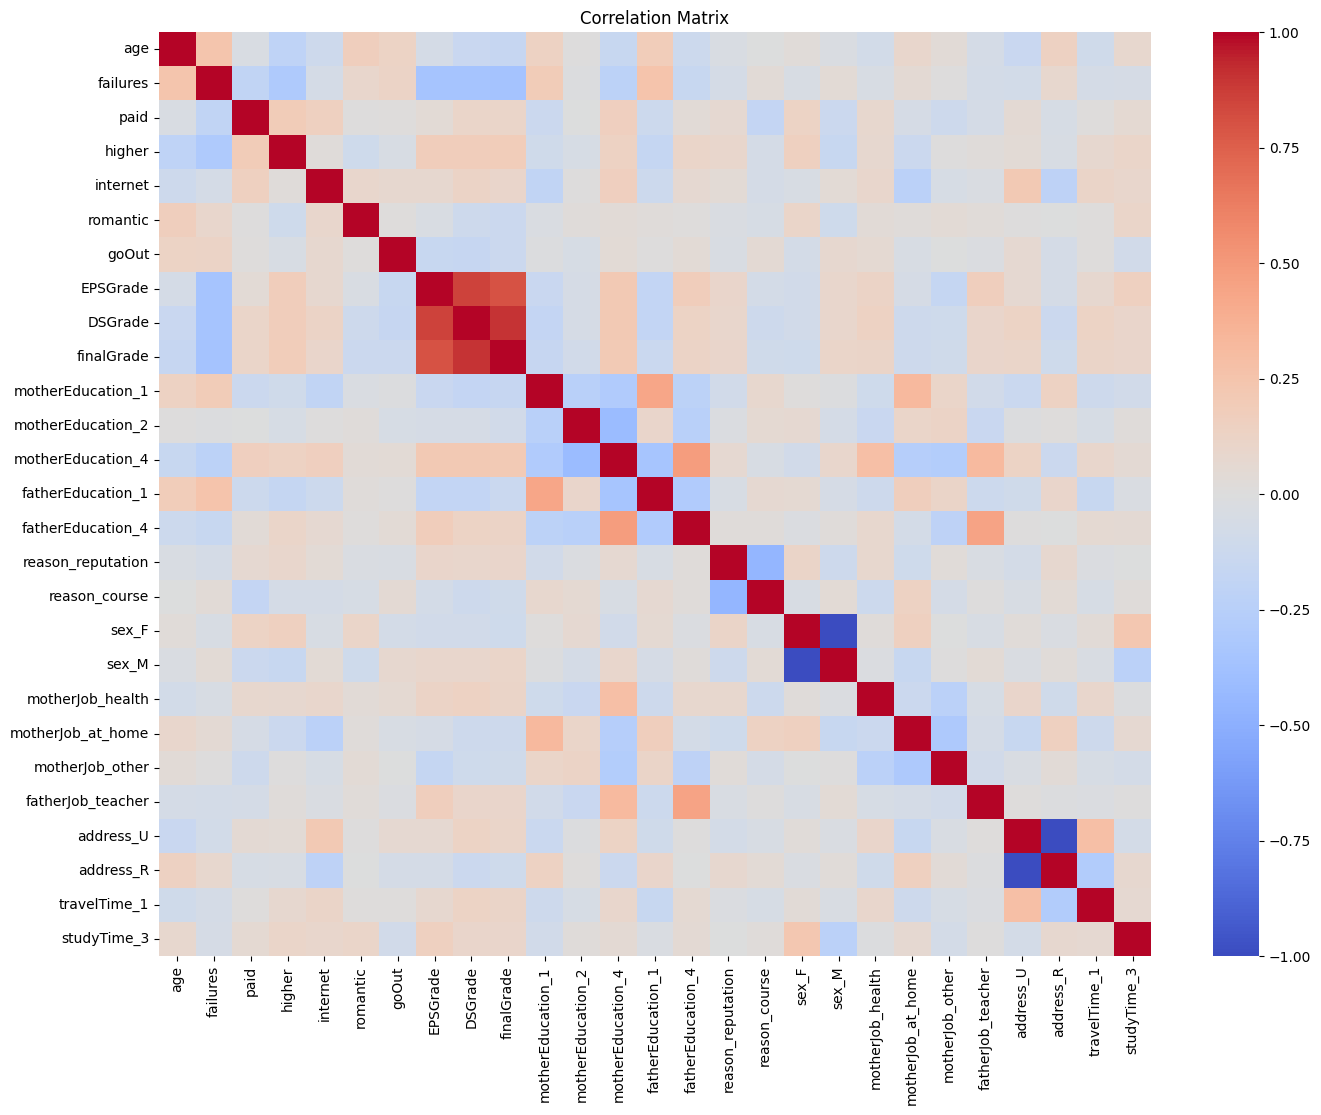

In [631]:
corr = train_df.corr(numeric_only=True)
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

- Add new features

In [632]:
add_features_df = pd.read_csv('Grades.csv')

In [633]:
train_df['parentEduMean'] = (add_features_df['fatherEducation'] + add_features_df['motherEducation']) / 2
train_df['avgGrade'] = (add_features_df['DSGrade'] + add_features_df['EPSGrade']) / 2
train_df['badHabits'] = add_features_df['Walc'] + add_features_df['Dalc'] + add_features_df['absences'] + add_features_df['failures']
corr = train_df[['parentEduMean', 'avgGrade', 'badHabits'] +['finalGrade']].corr(numeric_only=True)
print(corr['finalGrade'].sort_values(ascending=False))

finalGrade       1.000000
avgGrade         0.889792
parentEduMean    0.205224
badHabits       -0.012718
Name: finalGrade, dtype: float64


In [634]:
train_df.to_csv('preproccess.csv')

***Train-Test split***

Convert finalGrade to Classes

In [635]:
def grade_to_class(grade):
    if grade > 17:
        return 'A'
    elif grade > 15:
        return 'B'
    elif  grade > 10:
        return 'C'
    else:
        return 'F'

train_df['gradeClass'] = train_df['finalGrade'].apply(grade_to_class)

In [636]:
X = train_df.drop(columns=['finalGrade', 'gradeClass'])
y = train_df['gradeClass']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

***Normalization / Standardization***

Different methods:

    MinMaxScaler: Scales features to [0, 1]. Sensitive to outliers.

    StandardScaler: Scales to mean 0 and std 1. Common for most models.

    RobustScaler: Uses median and IQR, good for outliers.

    Log Transform: Useful for skewed distributions

We choose StandardScaler method.

In [637]:
features_to_scale = [
    'age', 'failures', 'freeTime', 'goOut', 'Dalc', 'Walc', 
    'absences', 'EPSGrade', 'DSGrade', 
    'parentEduMean', 'avgGrade', 'badHabits'
]

In [638]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
final_features_to_scale = [f for f in features_to_scale if f not in features_to_drop]
X_train_scaled[final_features_to_scale] = scaler.fit_transform(X_train[final_features_to_scale])
X_test_scaled = X_test.copy()
X_test_scaled[final_features_to_scale] = scaler.transform(X_test[final_features_to_scale])

***SKlean Models***

- Naive Bayes

In [639]:
model = GaussianNB()
model.fit(X_train, y_train)
y_pred_nb = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_nb)

precision_macro = precision_score(y_test, y_pred_nb, average='macro')
precision_micro = precision_score(y_test, y_pred_nb, average='micro')
precision_weighted = precision_score(y_test, y_pred_nb, average='weighted')

recall_macro = recall_score(y_test, y_pred_nb, average='macro')
recall_micro = recall_score(y_test, y_pred_nb, average='micro')
recall_weighted = recall_score(y_test, y_pred_nb, average='weighted')

f1_macro = f1_score(y_test, y_pred_nb, average='macro')
f1_micro = f1_score(y_test, y_pred_nb, average='micro')
f1_weighted = f1_score(y_test, y_pred_nb, average='weighted')

print(f"Accuracy: {accuracy:.4f}\n")

print("Precision Scores:")
print(f"  Macro:    {precision_macro:.4f}")
print(f"  Micro:    {precision_micro:.4f}")
print(f"  Weighted: {precision_weighted:.4f}\n")

print("Recall Scores:")
print(f"  Macro:    {recall_macro:.4f}")
print(f"  Micro:    {recall_micro:.4f}")
print(f"  Weighted: {recall_weighted:.4f}\n")

print("F1 Scores:")
print(f"  Macro:    {f1_macro:.4f}")
print(f"  Micro:    {f1_micro:.4f}")
print(f"  Weighted: {f1_weighted:.4f}")


Accuracy: 0.7215

Precision Scores:
  Macro:    0.6515
  Micro:    0.7215
  Weighted: 0.7879

Recall Scores:
  Macro:    0.8009
  Micro:    0.7215
  Weighted: 0.7215

F1 Scores:
  Macro:    0.6740
  Micro:    0.7215
  Weighted: 0.7256


- Decision Tree

Accuracy: 0.8861

Precision Scores:
  Macro:    0.8501
  Micro:    0.8861
  Weighted: 0.9018

Recall Scores:
  Macro:    0.7921
  Micro:    0.8861
  Weighted: 0.8861

F1 Scores:
  Macro:    0.7585
  Micro:    0.8861
  Weighted: 0.8737


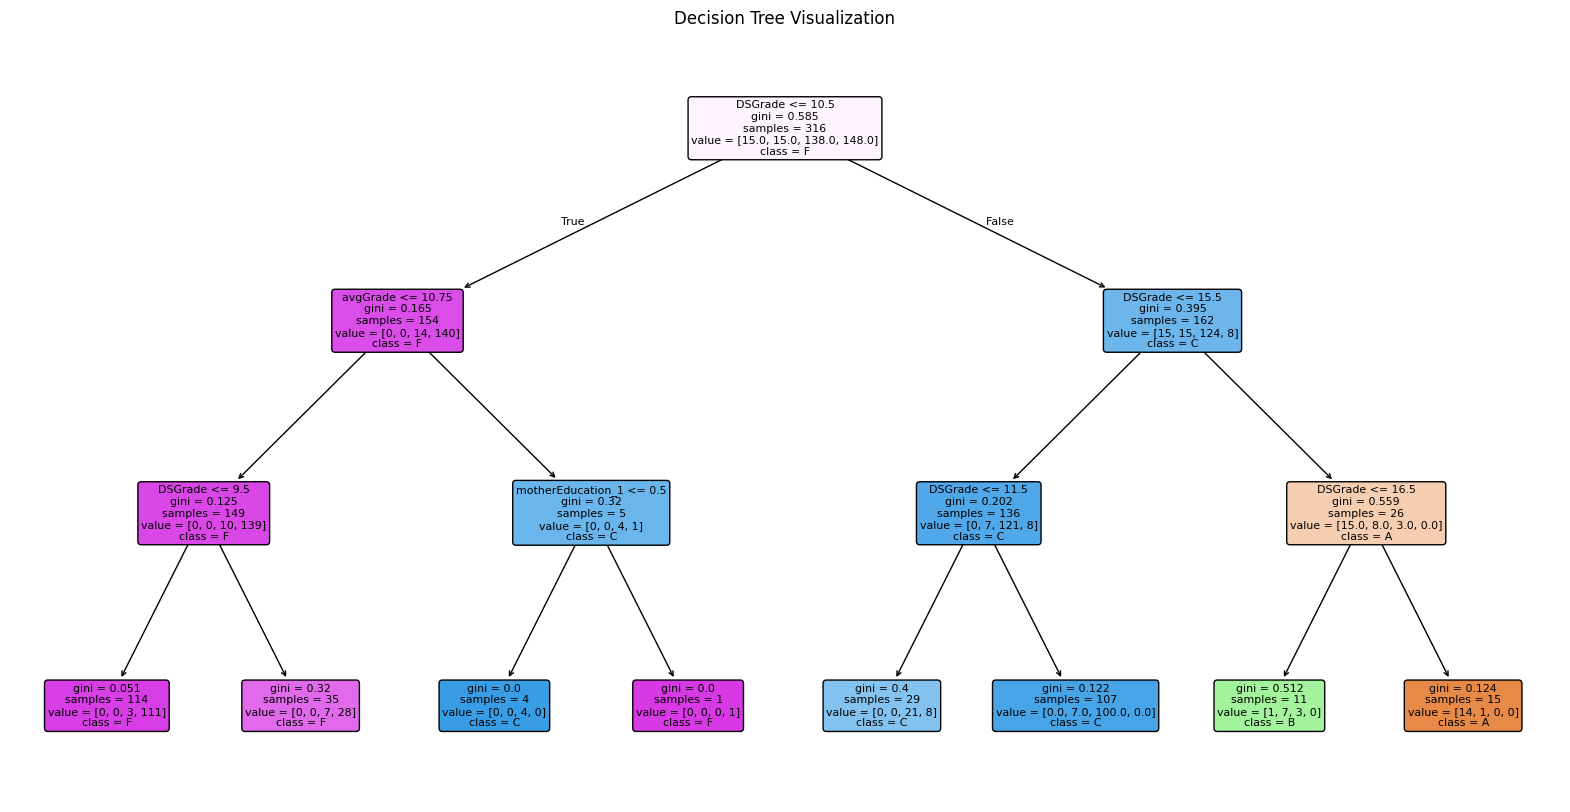

In [640]:
dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_dt = grid_search.best_estimator_
y_pred_dt = best_dt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_dt)

precision_macro = precision_score(y_test, y_pred_dt, average='macro')
precision_micro = precision_score(y_test, y_pred_dt, average='micro')
precision_weighted = precision_score(y_test, y_pred_dt, average='weighted')

recall_macro = recall_score(y_test, y_pred_dt, average='macro')
recall_micro = recall_score(y_test, y_pred_dt, average='micro')
recall_weighted = recall_score(y_test, y_pred_dt, average='weighted')

f1_macro = f1_score(y_test, y_pred_dt, average='macro')
f1_micro = f1_score(y_test, y_pred_dt, average='micro')
f1_weighted = f1_score(y_test, y_pred_dt, average='weighted')

print(f"Accuracy: {accuracy:.4f}\n")

print("Precision Scores:")
print(f"  Macro:    {precision_macro:.4f}")
print(f"  Micro:    {precision_micro:.4f}")
print(f"  Weighted: {precision_weighted:.4f}\n")

print("Recall Scores:")
print(f"  Macro:    {recall_macro:.4f}")
print(f"  Micro:    {recall_micro:.4f}")
print(f"  Weighted: {recall_weighted:.4f}\n")

print("F1 Scores:")
print(f"  Macro:    {f1_macro:.4f}")
print(f"  Micro:    {f1_micro:.4f}")
print(f"  Weighted: {f1_weighted:.4f}")

plt.figure(figsize=(20,10))
plot_tree(best_dt, feature_names=X.columns, class_names=[str(c) for c in best_dt.classes_], filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

Confusion Matrix:
[[ 3  0  0  0]
 [ 2  2  3  0]
 [ 0  0 29  2]
 [ 0  0  2 36]]


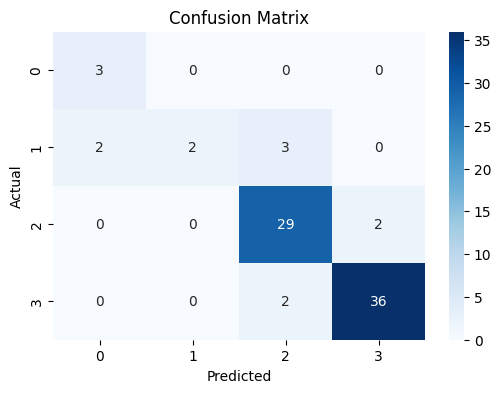

In [641]:
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_dt)
print(cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

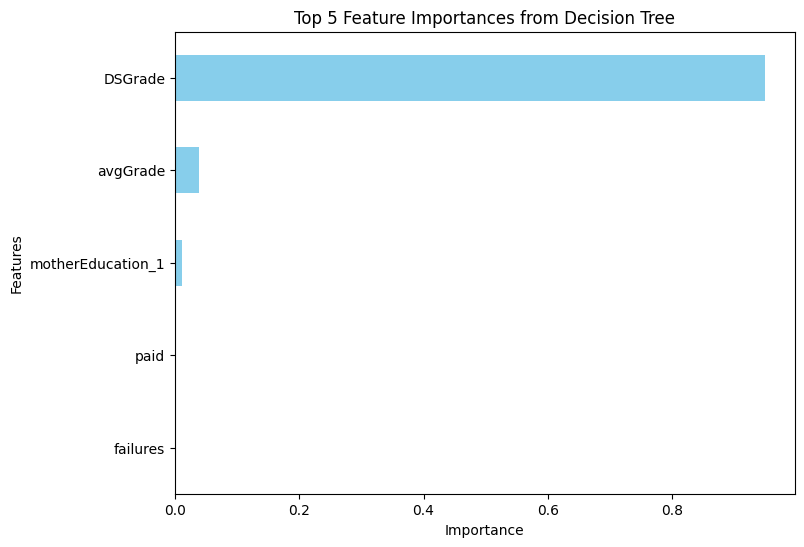

In [642]:
feature_importances = pd.Series(best_dt.feature_importances_, index=X.columns).sort_values(ascending=False)
top5_features = feature_importances.sort_values(ascending=False).head(5).sort_values(ascending=True)
plt.figure(figsize=(8, 6))
top5_features.plot(kind='barh', color='skyblue')
plt.title('Top 5 Feature Importances from Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

- Random Forest

In [ ]:
rf = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, 40],  
    'min_samples_split': [5, 10, 15],  
    'min_samples_leaf': [2, 4, 6],     
    'max_features': ['sqrt', 'log2'],  
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    cv=3,
    verbose=1,
    error_score=np.nan,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
best_rf = random_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_rf)
precision_macro = precision_score(y_test, y_pred_rf, average='macro')
precision_micro = precision_score(y_test, y_pred_rf, average='micro')
precision_weighted = precision_score(y_test, y_pred_rf, average='weighted')

recall_macro = recall_score(y_test, y_pred_rf, average='macro')
recall_micro = recall_score(y_test, y_pred_rf, average='micro')
recall_weighted = recall_score(y_test, y_pred_rf, average='weighted')

f1_macro = f1_score(y_test, y_pred_rf, average='macro')
f1_micro = f1_score(y_test, y_pred_rf, average='micro')
f1_weighted = f1_score(y_test, y_pred_rf, average='weighted')

print(f"Accuracy: {accuracy:.4f}\n")

print("Precision Scores:")
print(f"  Macro:    {precision_macro:.4f}")
print(f"  Micro:    {precision_micro:.4f}")
print(f"  Weighted: {precision_weighted:.4f}\n")

print("Recall Scores:")
print(f"  Macro:    {recall_macro:.4f}")
print(f"  Micro:    {recall_micro:.4f}")
print(f"  Weighted: {recall_weighted:.4f}\n")

print("F1 Scores:")
print(f"  Macro:    {f1_macro:.4f}")
print(f"  Micro:    {f1_micro:.4f}")
print(f"  Weighted: {f1_weighted:.4f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Accuracy: 0.8861

Precision Scores:
  Macro:    0.8325
  Micro:    0.8861
  Weighted: 0.9120

Recall Scores:
  Macro:    0.7645
  Micro:    0.8861
  Weighted: 0.8861

F1 Scores:
  Macro:    0.6964
  Micro:    0.8861
  Weighted: 0.8660


Confusion Matrix:
[[ 3  0  0  0]
 [ 3  1  3  0]
 [ 0  0 30  1]
 [ 0  0  2 36]]


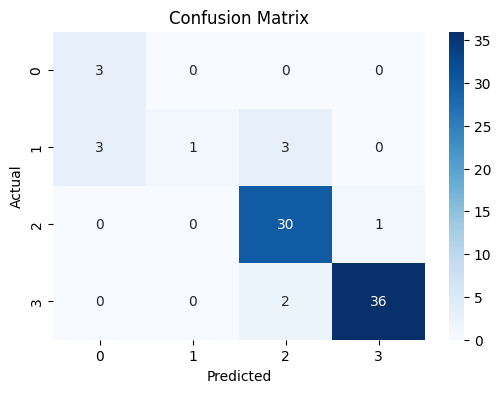

In [644]:
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


- XGBoost

In [645]:
le = LabelEncoder()
y_encoded = le.fit_transform(y) 
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'min_split_loss': [0, 0.1, 0.2],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_xgb = grid_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_xgb)
precision_macro = precision_score(y_test, y_pred_xgb, average='macro')
precision_micro = precision_score(y_test, y_pred_xgb, average='micro')
precision_weighted = precision_score(y_test, y_pred_xgb, average='weighted')

recall_macro = recall_score(y_test, y_pred_xgb, average='macro')
recall_micro = recall_score(y_test, y_pred_xgb, average='micro')
recall_weighted = recall_score(y_test, y_pred_xgb, average='weighted')

f1_macro = f1_score(y_test, y_pred_xgb, average='macro')
f1_micro = f1_score(y_test, y_pred_xgb, average='micro')
f1_weighted = f1_score(y_test, y_pred_xgb, average='weighted')

print(f"Accuracy: {accuracy:.4f}\n")

print("Precision Scores:")
print(f"  Macro:    {precision_macro:.4f}")
print(f"  Micro:    {precision_micro:.4f}")
print(f"  Weighted: {precision_weighted:.4f}\n")

print("Recall Scores:")
print(f"  Macro:    {recall_macro:.4f}")
print(f"  Micro:    {recall_micro:.4f}")
print(f"  Weighted: {recall_weighted:.4f}\n")

print("F1 Scores:")
print(f"  Macro:    {f1_macro:.4f}")
print(f"  Micro:    {f1_micro:.4f}")
print(f"  Weighted: {f1_weighted:.4f}")

Fitting 3 folds for each of 729 candidates, totalling 2187 fits
Accuracy: 0.8734

Precision Scores:
  Macro:    0.7656
  Micro:    0.8734
  Weighted: 0.8705

Recall Scores:
  Macro:    0.7841
  Micro:    0.8734
  Weighted: 0.8734

F1 Scores:
  Macro:    0.7431
  Micro:    0.8734
  Weighted: 0.8630


***Decision Tree from Scratch***

In [646]:
class DecisionTreeScratch:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def entropy(self, y):
        if len(y) == 0:
            return 0
        counts = np.bincount(y)
        probabilities = counts[counts > 0] / len(y)
        return -np.sum(probabilities * np.log2(probabilities))

    def information_gain(self, y, y_left, y_right):
        previous_entropy = self.entropy(y)
        n = len(y)
        n_left, n_right = len(y_left), len(y_right)
        left_part = (n_left / n) * self.entropy(y_left)
        right_part = (n_right / n) * self.entropy(y_right)
        next_entropy = left_part + right_part
        gain = previous_entropy - next_entropy
        return gain

    def best_split(self, X, y):
        best_gain = -1
        best_feature = None
        best_threshold = None
        n_features = X.shape[1]
        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask

                if sum(left_mask) < self.min_samples_split or sum(right_mask) < self.min_samples_split:
                    continue

                y_left, y_right = y[left_mask], y[right_mask]
                gain = self.information_gain(y, y_left, y_right)

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold
        return best_feature, best_threshold, best_gain

    def build_tree(self, X, y, depth=0):
        if not isinstance(X, np.ndarray):
            X = X.to_numpy()
        if not isinstance(y, np.ndarray):
            y = y.to_numpy()

        num_samples, num_features = X.shape
        num_labels = len(np.unique(y))

        if (depth >= self.max_depth or num_labels == 1 or num_samples < self.min_samples_split):
            leaf_label = Counter(y).most_common(1)[0][0]
            return {'type': 'leaf', 'class': leaf_label}

        feature, threshold, gain = self.best_split(X, y)

        if gain <= 0 or feature is None:
            leaf_label = Counter(y).most_common(1)[0][0]
            return {'type': 'leaf', 'class': leaf_label}

        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold

        left_X, left_y = X[left_mask], y[left_mask]
        right_X, right_y = X[right_mask], y[right_mask]

        left_subtree = self.build_tree(left_X, left_y, depth + 1)
        right_subtree = self.build_tree(right_X, right_y, depth + 1)

        return {
            'type': 'node',
            'feature': feature,
            'threshold': threshold,
            'left': left_subtree,
            'right': right_subtree
        }

    def fit(self, X, y):
        if not isinstance(X, np.ndarray):
            X = X.to_numpy()
        if not isinstance(y, np.ndarray):
            y = y.to_numpy()
        self.tree = self.build_tree(X, y)

    def predict_one(self, x, node):
        if node['type'] == 'leaf':
            return node['class']
        feature = node['feature']
        threshold = node['threshold']

        if feature >= len(x):
            raise IndexError(f"Feature index {feature} out of bounds for input with length {len(x)}")

        if x[feature] <= threshold:
            return self.predict_one(x, node['left'])
        else:
            return self.predict_one(x, node['right'])

    def predict(self, X):
        if not isinstance(X, np.ndarray):
            X = X.to_numpy()
        return np.array([self.predict_one(x, self.tree) for x in X])


***Comparison with Library Implementation***

In [647]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
dt = DecisionTreeScratch(max_depth=4)
dt.fit(X_train, y_train)
y_pred_my_dt = dt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_my_dt)
precision_macro = precision_score(y_test, y_pred_my_dt, average='macro')
precision_micro = precision_score(y_test, y_pred_my_dt, average='micro')
precision_weighted = precision_score(y_test, y_pred_my_dt, average='weighted')

recall_macro = recall_score(y_test, y_pred_my_dt, average='macro')
recall_micro = recall_score(y_test, y_pred_my_dt, average='micro')
recall_weighted = recall_score(y_test, y_pred_my_dt, average='weighted')

f1_macro = f1_score(y_test, y_pred_my_dt, average='macro')
f1_micro = f1_score(y_test, y_pred_my_dt, average='micro')
f1_weighted = f1_score(y_test, y_pred_my_dt, average='weighted')

print(f"Accuracy: {accuracy:.4f}\n")

print("Precision Scores:")
print(f"  Macro:    {precision_macro:.4f}")
print(f"  Micro:    {precision_micro:.4f}")
print(f"  Weighted: {precision_weighted:.4f}\n")

print("Recall Scores:")
print(f"  Macro:    {recall_macro:.4f}")
print(f"  Micro:    {recall_micro:.4f}")
print(f"  Weighted: {recall_weighted:.4f}\n")

print("F1 Scores:")
print(f"  Macro:    {f1_macro:.4f}")
print(f"  Micro:    {f1_micro:.4f}")
print(f"  Weighted: {f1_weighted:.4f}\n")

X_train shape: (316, 29)
X_test shape: (79, 29)
Accuracy: 0.8734

Precision Scores:
  Macro:    0.8434
  Micro:    0.8734
  Weighted: 0.8893

Recall Scores:
  Macro:    0.7549
  Micro:    0.8734
  Weighted: 0.8734

F1 Scores:
  Macro:    0.7059
  Micro:    0.8734
  Weighted: 0.8503

